In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

tf.keras.utils.set_random_seed(42)

1. Ladda data

In [2]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\nadin\Documents\Deep Learning Uppgift\FER-2013\train",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\nadin\Documents\Deep Learning Uppgift\FER-2013\train",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\nadin\Documents\Deep Learning Uppgift\FER-2013\test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [3]:
# Skapa en mindre dataset

num_classes = len(train_ds_full.class_names)
samples_per_class = 2000

train_unbatched = train_ds_full.unbatch()

small_train_list = []

for class_idx in range(num_classes):

    class_ds = train_unbatched.filter(
        lambda x, y: tf.equal(y, class_idx)
    )

    class_ds = class_ds.shuffle(5000, seed=42)
    class_ds = class_ds.take(samples_per_class)
    small_train_list.append(class_ds)

train_ds = small_train_list[0]
for ds in small_train_list[1:]:
    train_ds = train_ds.concatenate(ds)

train_ds = train_ds.batch(32)

#val_ds = val_ds_full.unbatch().shuffle(5000, seed=42).take(200 * num_classes).batch(32)
#test_ds = test_ds_full.unbatch().shuffle(5000, seed=42).take(200 * num_classes).batch(32)

val_ds = val_ds_full
test_ds = test_ds_full

In [4]:
# Visa klasser

class_names = train_ds_full.class_names
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
class_counts = {cls: 0 for cls in class_names}

for images, labels in train_ds.unbatch():
    class_name = class_names[labels.numpy()]
    class_counts[class_name] += 1

print("Antal bilder per klass i train:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Antal bilder per klass i train:
angry: 2000
disgust: 363
fear: 2000
happy: 2000
neutral: 2000
sad: 2000
surprise: 2000


För att träna modellen användes FER-2013-datasetet, som innehåller bilder av ansiktsuttryck uppdelade i sju klasser: angry, disgust, fear, happy, neutral, sad och surprise. Datasetet är dock obalanserat, där vissa klasser (t.ex. happy) innehåller betydligt fler bilder än andra (t.ex. disgust).

För att förbättra träningsprocessen och minska risken för att modellen blir biased mot majoritetsklasser skapades därför ett mindre, balanserat dataset. Detta gjordes genom att välja upp till 2000 bilder per klass från träningsdatan.

Det bör dock noteras att inte alla klasser innehöll 2000 bilder. Till exempel hade klassen disgust betydligt färre bilder, vilket innebar att endast de tillgängliga exemplen kunde användas för denna klass. Detta är en direkt konsekvens av den ursprungliga obalansen i datasetet.

Denna metod säkerställer att modellen tränas på en så jämn fördelning som möjligt mellan klasserna, vilket gör att den får bättre möjlighet att lära sig kännetecken för alla uttryck istället för att favorisera de mest förekommande klasserna.

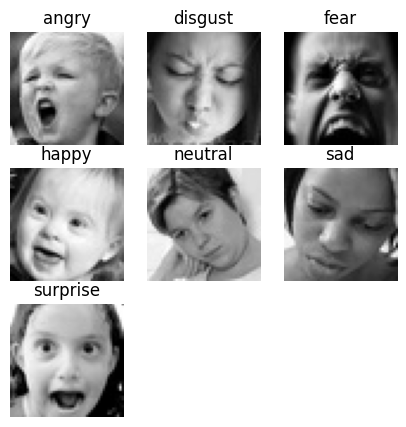

In [6]:
plt.figure(figsize=(5,5))

# visa en bild per klass
taken_classes = set()
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in taken_classes:
        img = images.numpy().squeeze()
        plt.subplot(3, 3, len(taken_classes)+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_names[label])
        plt.axis('off')
        taken_classes.add(label)
    if len(taken_classes) == len(class_names):
        break

plt.show()

In [7]:
# Normalisera
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Performance pipeline
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(tf.data.AUTOTUNE)

3. Bygg en modell

In [8]:
# Basmodell

model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),
    
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),
    
    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
    # Fully connected
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    # Output
    layers.Dense(len(class_names), activation='softmax')
])

# Kompile modellen

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,423 (2.61 MB)

 Trainable params: 683,975 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Model 2 : fokus på mindre overfitting. Jag testar data augmentation och mer dropout.

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model2 = models.Sequential([

    layers.Input(shape=(48, 48, 1)),

    # Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    
    # Output
    layers.Dense(len(class_names), activation='softmax')
])

# Kompile modellen

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Model 3: Djupare model, fler conv-lager

model3 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')
])

model3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

4. Träna modellen

In [11]:
# Träna model 1:

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
    387/Unknown 83s 71ms/step - accuracy: 0.1644 - loss: 2.5989

c:\Users\nadin\Documents\Deep Learning Uppgift\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


387/387 ━━━━━━━━━━━━━━━━━━━━ 87s 82ms/step - accuracy: 0.1775 - loss: 2.1540 - val_accuracy: 0.1911 - val_loss: 3.2755
Epoch 2/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.2066 - loss: 1.8852 - val_accuracy: 0.2451 - val_loss: 1.8434
Epoch 3/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.2512 - loss: 1.8410 - val_accuracy: 0.2754 - val_loss: 1.7862
Epoch 4/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.2731 - loss: 1.7838 - val_accuracy: 0.3019 - val_loss: 1.7246
Epoch 5/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.2907 - loss: 1.7579 - val_accuracy: 0.2904 - val_loss: 1.7408
Epoch 6/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.3262 - loss: 1.6940 - val_accuracy: 0.3377 - val_loss: 1.6924
Epoch 7/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 44s 113ms/step - accuracy: 0.3446 - loss: 1.6501 - val_accuracy: 0.3419 - val_loss: 1.6652
Epoch 8/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.3568 - loss: 1.6155 - val_accur

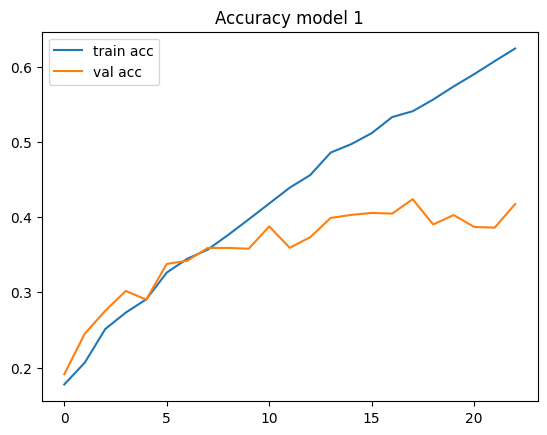

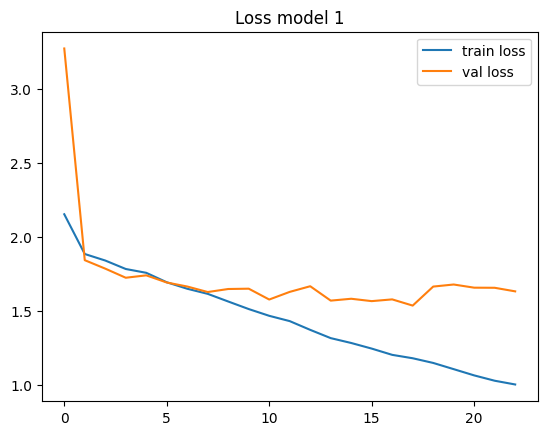

In [12]:
# Träningskurvor

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy model 1")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss model 1")
plt.show()

In [13]:
# Träna model 2:

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 60s 136ms/step - accuracy: 0.1640 - loss: 2.2868 - val_accuracy: 0.0935 - val_loss: 2.7827
Epoch 2/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - accuracy: 0.1611 - loss: 1.9500 - val_accuracy: 0.2273 - val_loss: 1.8946
Epoch 3/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 51s 132ms/step - accuracy: 0.1775 - loss: 1.9342 - val_accuracy: 0.2277 - val_loss: 1.8775
Epoch 4/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 51s 132ms/step - accuracy: 0.1857 - loss: 1.9241 - val_accuracy: 0.2338 - val_loss: 1.8681
Epoch 5/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 51s 132ms/step - accuracy: 0.1916 - loss: 1.9084 - val_accuracy: 0.2378 - val_loss: 1.8429
Epoch 6/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - accuracy: 0.2010 - loss: 1.8963 - val_accuracy: 0.2409 - val_loss: 1.8254
Epoch 7/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.2067 - loss: 1.8821 - val_accuracy: 0.2219 - val_loss: 1.8744
Epoch 8/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 51s 132ms/step - accuracy: 0.2138 - loss: 1

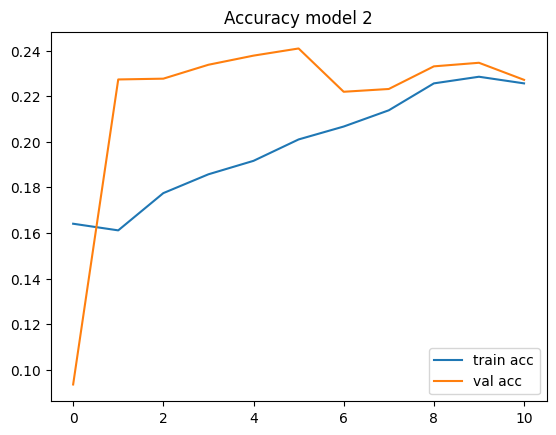

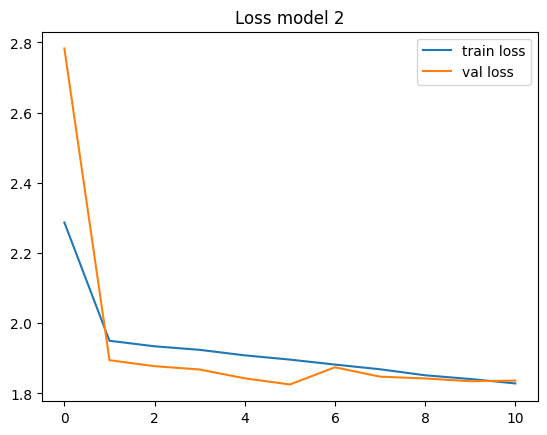

In [14]:
# Träningskurvor

plt.plot(history2.history['accuracy'], label='train acc')
plt.plot(history2.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy model 2")
plt.show()

plt.plot(history2.history['loss'], label='train loss')
plt.plot(history2.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss model 2")
plt.show()

In [15]:
# Träna model 3:

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 111s 256ms/step - accuracy: 0.1730 - loss: 2.0160 - val_accuracy: 0.1658 - val_loss: 1.8803
Epoch 2/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 98s 252ms/step - accuracy: 0.1754 - loss: 1.9332 - val_accuracy: 0.1709 - val_loss: 1.8627
Epoch 3/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 96s 249ms/step - accuracy: 0.1956 - loss: 1.8976 - val_accuracy: 0.1756 - val_loss: 1.8484
Epoch 4/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 97s 250ms/step - accuracy: 0.2172 - loss: 1.8651 - val_accuracy: 0.1693 - val_loss: 1.8413
Epoch 5/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 92s 238ms/step - accuracy: 0.2270 - loss: 1.8393 - val_accuracy: 0.1754 - val_loss: 1.8428
Epoch 6/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 69s 178ms/step - accuracy: 0.2609 - loss: 1.7993 - val_accuracy: 0.1808 - val_loss: 1.8553
Epoch 7/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 59s 153ms/step - accuracy: 0.2815 - loss: 1.7684 - val_accuracy: 0.1686 - val_loss: 1.8537
Epoch 8/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 59s 153ms/step - accuracy: 0.3121 - loss: 

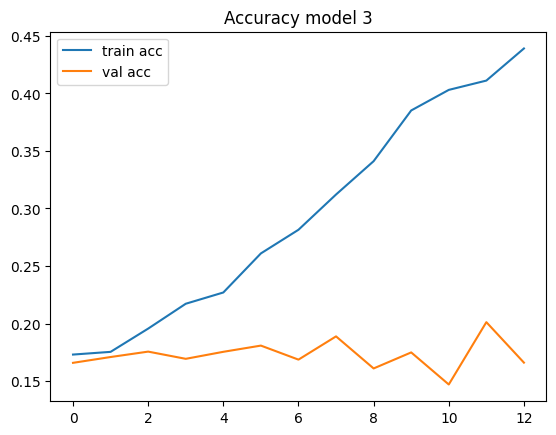

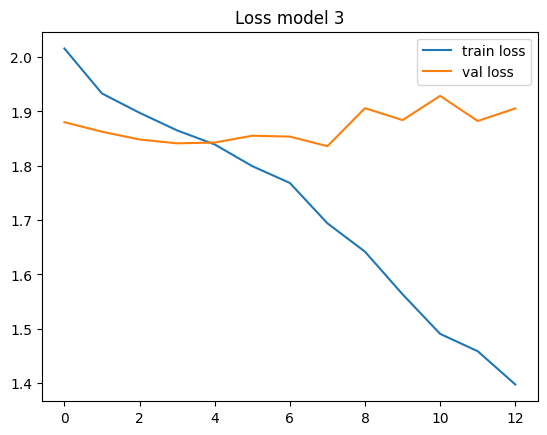

In [16]:
# Träningskurvor

plt.plot(history3.history['accuracy'], label='train acc')
plt.plot(history3.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy model 3")
plt.show()

plt.plot(history3.history['loss'], label='train loss')
plt.plot(history3.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss model 3")
plt.show()

In [18]:
# Jämförelse

results = {
    "Modell": ["CNN Model 1", "CNN Model 2", "CNN Model 3"],

    "Training Accuracy": [
        history.history['accuracy'][-1],
        history2.history['accuracy'][-1],
        history3.history['accuracy'][-1]
    ],

    "Validation Accuracy": [
        history.history['val_accuracy'][-1],
        history2.history['val_accuracy'][-1],
        history3.history['val_accuracy'][-1]
    ],

    "Training Loss": [
        history.history['loss'][-1],
        history2.history['loss'][-1],
        history3.history['loss'][-1]
    ],

    "Validation Loss": [
        history.history['val_loss'][-1],
        history2.history['val_loss'][-1],
        history3.history['val_loss'][-1]
    ]
}

df_results = pd.DataFrame(results)

# Tabell
df_results.style.format({
    "Training Accuracy": "{:.4f}",
    "Validation Accuracy": "{:.4f}",
    "Training Loss": "{:.4f}",
    "Validation Loss": "{:.4f}"
})

,Modell,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,CNN Model 1,0.6240,0.4173,1.0025,1.6325
1,CNN Model 2,0.2256,0.2271,1.8284,1.8364
2,CNN Model 3,0.4391,0.1660,1.3972,1.9057


- Jämföra modeller

Jag testade tre olika modeller med olika arkitekturer och nivåer av komplexitet. Resultaten varierar mycket.

Flera förändringar testades, såsom djupare nätverk, mer dropout och data augmentation. Resultaten visar att dessa förändringar inte nödvändigtvis ledde till bättre prestanda i detta fall.

Model 1 presterade bäst med en validation accuracy på cirka 0.42. Model 2 och Model 3 presterade sämre både på training och validation, vilket tyder på att ökad komplexitet inte alltid förbättrar resultaten. I vissa fall kan det istället göra träningen svårare eller leda till sämre generalisering.

- Analys och diskussion

Genom att jämföra träningskurvorna syns att Model 1 har den bästa balansen mellan training och validation accuracy. Model 2 och Model 3 visar lägre performance och ingen tydlig förbättring över epochs.

Skillnaderna mellan modellerna kan förklaras av att datasetet är relativt litet och svårt, vilket gör att mer komplexa modeller riskerar att överanpassa.

Resultaten visar att modellernas prestanda begränsas av datasetets kvalitet och komplexitet. Eftersom bilderna i FER2013 är lågupplösta och emotioner ibland överlappar varandra, är det svårt att uppnå mycket hög accuracy.

Modellen visar också att deep learning inte alltid leder till bättre resultat när datamängden är begränsad eller brusig. I sådana fall kan enklare modeller ibland prestera lika bra eller bättre.

En viktig begränsning är att modellerna tränas från scratch. Mer avancerade metoder som transfer learning hade sannolikt kunnat förbättra resultaten.


5. Utvärdera modellen

Baserat på resultaten från valideringsdatan bedöms Model 1 som den bäst presterande modellen. Denna modell används därför för slutlig utvärdering på testdatan.

In [19]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4238 - loss: 1.5304
Test loss: 1.5304
Test accuracy: 0.4238


Test accuracy ligger nära validation accuracy (cirka 0.42), vilket tyder på att modellen generaliserar konsekvent, även om prestandan inte är särskilt hög. Detta indikerar att modellen inte överanpassar testdatan, men samtidigt har begränsad förmåga att korrekt klassificera emotioner.

Även om modellen inte uppnår hög accuracy visar resultaten att den kan lära sig vissa mönster i datan, men att generalisering fortfarande är en utmaning på detta dataset.

In [21]:
# Confusion matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━

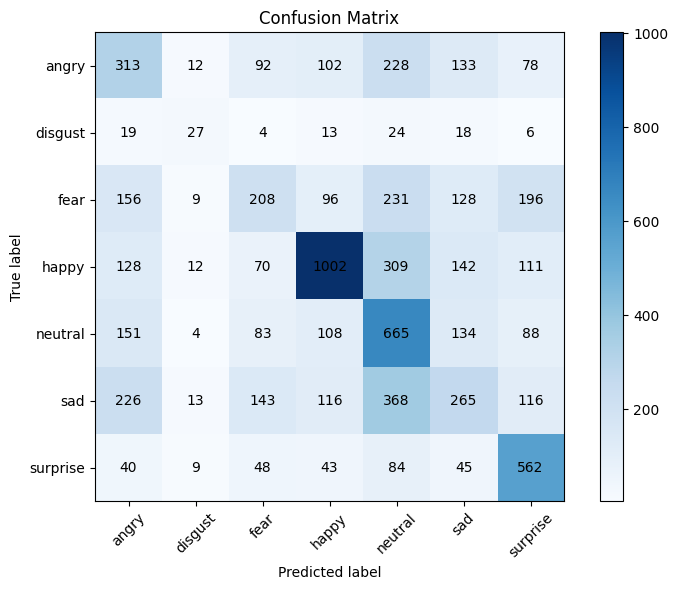

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap='Blues')

plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# skriv siffror i rutorna
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='black')

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

Confusion matrixen visar hur modellen klassificerar de olika emotionerna.

Det tydligaste resultatet är att vissa klasser fungerar mycket bättre än andra. Klassen happy har flest korrekta klassificeringar, vilket visar att modellen lättare känner igen tydliga positiva uttryck.

Även neutral och surprise har relativt många korrekta klassificeringar jämfört med andra klasser.

Vissa emotioner är betydligt svårare för modellen:

Disgust har väldigt få korrekta prediktioner

Fear förväxlas ofta med andra klasser

Sad blandas ofta med neutral och fear

Angry förväxlas ofta med fear och neutral

Detta visar att modellen har svårt att skilja mellan emotioner som har liknande ansiktsuttryck.

Resultaten visar att modellen är ojämn i sin klassificering. Den fungerar bra för tydliga uttryck som happy, men har stora svårigheter med subtila eller liknande emotioner.

6. Gör prediktioner på ny data

In [23]:
# Ladda bild från testdata

img_path = r"C:\Users\nadin\Documents\Deep Learning Uppgift\FER-2013\test\happy\PrivateTest_647018.jpg"

img = tf.keras.utils.load_img(
    img_path,
    color_mode="grayscale",
    target_size=(48, 48)
)

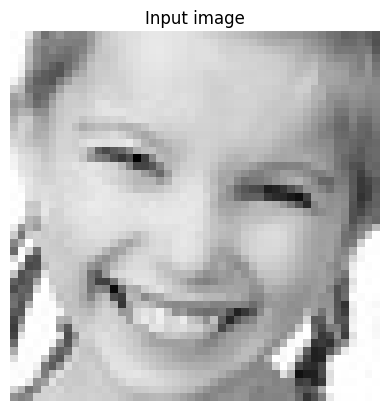

In [24]:
# Visa bilden

plt.imshow(img, cmap='gray')
plt.title("Input image")
plt.axis("off")
plt.show()

In [25]:
# Förbered bilden så att den matchar training pipeline

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0  # samma normalization som träning
img_array = np.expand_dims(img_array, axis=0)  # batch dimension

In [26]:
# Gör prediktion

predictions = model.predict(img_array)
predicted_class = np.argmax(predictions)

print("Predicted class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted class: happy


In [27]:
# Visa sannolikheter

for i, prob in enumerate(predictions[0]):
    print(f"{class_names[i]}: {prob:.3f}")

angry: 0.024
disgust: 0.000
fear: 0.020
happy: 0.896
neutral: 0.047
sad: 0.005
surprise: 0.007


Modellen klassificerade bilden korrekt som happy med hög sannolikhet, vilket visar att den fungerar bra för tydliga ansiktsuttryck.

7. Analysera resultatet

- Hur bra fungerar modellen?

Modellen fungerar relativt bra med tanke på att FER2013 är ett svårt dataset. Modellen uppnådde ungefär 60% accuracy på träningsdatan och cirka 42% på både validerings- och testdatan. Resultatet visar att modellen kan lära sig vissa mönster i ansiktsuttrycken och klassificera emotioner bättre än slumpen, men den har fortfarande svårt att generalisera till nya bilder.

För en enklare CNN-modell utan transfer learning är detta ett rimligt resultat.

- Ser du tecken på overfitting eller underfitting?

Ja, modellen visar tydliga tecken på overfitting. Träningsaccuracyn är betydligt högre än validation- och test-accuracyn.
Det betyder att modellen lär sig träningsdatan ganska bra men har svårare att prestera på nya bilder som den inte har sett tidigare. Skillnaden mellan train och validation/test visar att modellen delvis memorerar träningsdatan istället för att generalisera.

Det finns däremot inte så starka tecken på underfitting eftersom modellen ändå lyckas lära sig mönster och nå relativt hög train accuracy.

- Hur skiljer sig modellens resultat mellan träningsdata och testdata?

Resultatet är tydligt bättre på träningsdatan än på testdatan. Skillnaden är ganska stor mellan training accuracy och test accuracy.

Det visar att modellen fungerar bättre på bilder den redan har tränats på än på helt nya bilder. Validation- och testresultaten ligger också nära varandra, vilket tyder på att testresultatet är stabilt och att modellen generaliserar ungefär lika dåligt på båda dataseten.

- Vad verkar påverka resultatet mest?

Flera faktorer verkar påverka resultatet:

Datasetet är svårt eftersom bilderna är små (48x48 pixlar) och i gråskala.

FER2013 innehåller en del brusiga eller felmärkta bilder.

Vissa emotioner är svåra att skilja åt, till exempel fear och surprise.

Datasetet är obalanserat, vilket gör att vissa klasser lärs bättre än andra.

Modellen är relativt enkel och har begränsad kapacitet jämfört med modernare arkitekturer.

Overfitting verkar också påverka resultatet mycket, eftersom modellen presterar betydligt bättre på träningsdatan än på testdatan.

- Vilka begränsningar har din modell?

Modellen har flera begränsningar:

Den använder endast gråskalebilder med låg upplösning, vilket gör det svårt att fånga detaljer i ansiktsuttryck. Jag använde inte hela datasetet heller.

Modellen är relativt liten och enkel jämfört med djupare nätverk som ResNet eller EfficientNet.

Den generaliserar inte tillräckligt bra och visar tecken på overfitting.

Vissa emotioner är svåra att klassificera korrekt eftersom ansiktsuttrycken kan likna varandra.

Ingen transfer learning användes, vilket ofta ger betydligt bättre resultat inom bildklassificering.

Modellen kan påverkas negativt av dålig belysning, ansiktsvinklar och brus i bilderna.

8. Reflektion

- Vad var svårast i uppgiften?

Det svåraste i uppgiften var att förbättra modellens accuracy, särskilt validation accuracy. Det var svårt att veta hur mycket modellen realistiskt kunde förbättras och när resultatet kunde anses vara tillräckligt bra. Datasetet är relativt svårt eftersom bilderna har låg upplösning och emotionerna ofta liknar varandra. Dessutom tar det tid att testa olika förändringar i modellen eftersom varje experiment kräver ny träning och utvärdering.

En annan utmaning var att FER2013 är ett ganska svårt dataset med lågupplösta bilder och emotioner som ofta liknar varandra.

- Vad lärde du dig?

Jag lärde mig hur man bygger och tränar en CNN-modell för bildklassificering med TensorFlow och Keras. Jag fick också bättre förståelse för:

Hur convolutional layers fungerar

Varför batch normalization och dropout används

Hur man använder validation data och early stopping

Skillnaden mellan training accuracy och validation/test accuracy

Vad overfitting innebär i praktiken

Hur olika hyperparametrar påverkar modellens resultat

Jag lärde mig också att det inte alltid räcker att göra modellen större för att få bättre resultat, utan att datakvalitet och generalisering är väldigt viktiga.

- Vad hade du gjort annorlunda om du började om?

Om jag skulle har haft mer tid hade jag testat fler metoder för att minska overfitting, till exempel data augmentation och class weights. Jag hade också experimenterat mer med olika hyperparametrar som learning rate, dropout och antal lager.


- Vilket betyg tycker du att din inlämning motsvarar, G eller VG?

Jag anser att min inlämning motsvarar VG-nivå eftersom jag uppfyller kraven för G genom att bygga och utvärdera en fungerande CNN-modell samt göra prediktioner och en grundläggande analys av resultatet, inklusive overfitting.

För VG har jag dessutom testat och jämfört flera modellvarianter, analyserat träningskurvor och resultat, samt förklarat skillnader mellan modellerna. Jag har även gjort en confusion matrix och en kritisk diskussion kring modellens begränsningar, datans kvalitet och generalisering.


In [28]:
# Spara model 1

model.save("model.keras")